In [65]:
#from pathlib import Path
import sys
sys.path.append('..')
import random, math, string
import matplotlib.pyplot as plt

# 01 — Output

Covers `karpathy.py` lines 244–276, the *Machine Learning - Output* section, plus
the imports at lines 1–2 and `softmax` from lines 75–79: taking a model that already exists and drawing text
out of it.

Nothing here trains anything. `generate` asks some function for a score over every
possible next token, turns those scores into probabilities, draws one, and repeats.
Which function it asks is an argument — `logit_model` — so the last section swaps
in a model built entirely out of counting, and no neural network appears in this
notebook at all.

Code cells reproduce the source verbatim, dedented where a fragment sits inside a
function. Anything that is *not* from the source is marked as such.

Let's talk about generating sequences of tokens.

The tokens might be letters in english names, or words in the lyrics of the first three Beatles albums. We don't know and iMt doesn't matter. If we have an "alphabet" or "vacabulary" of $n$ tokens, a reasonable thing to do would be to give each token a probability, then sample according to that. Remember that a probability distribution looks like:

$$
P = \{ p_i \in [0,1] \mid \sum p_i = 1 \}
$$

So, for example, given a vocabulary of three tokens $T=\{ t_1, t_2, t_3 \}$ like $[A,B,C]$ we might have $P=\{ 0.5, 0.25, 0.25 \}$ we know the first token s twice as often as the others. We can generate according to this simple model easily:

In [ ]:
random.choices(['a', 'b', 'c'], weights=[0.5, 0.25, 0.25],k=10)

## Logits and probabilitie
_lines 75–79_

Sometimes dealing with real probabilities is a hassle or for experimental reasons we'd like to use something more like _weights_. It would be almost the same to say $\{ 61, 29, 31 \}$. Logits are a nice way to do that - they are simply a mapping from probabilites onto the whole line, thus:


$$
\begin{align}
\mathit{logit} &: [0,1] \to \mathbb{R} \\
& p \mapsto \ln( \frac{p}{1-p} )
\end{align}
$$

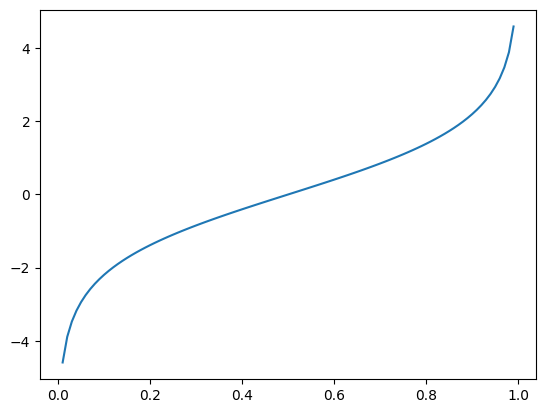

In [1]:
import math
def logit(p):
    return math.log(p/(1.0-p))

X=[x/100.0 for x in range(1,100)]
Y=[ logit(x) for x in X]
plt.plot(X,Y)

We get from `logits` back to probabilities with `softmax()`. We'll import a Value class we'll build compututation infrastructure later - for now, just think of them as Real that you have to get at with `.value()`.

In [17]:
from karpathy import Value

In [25]:
def softmax(logits):
    max_val = max(val.data for val in logits)
    exps = [(val - max_val).exp() for val in logits]
    total = sum(exps)
    return [e / total for e in exps]

What happens to a distribution across a vocabulary of size 3 as we map it to logits, then apply a Temperature transformation.

In [46]:
p1 = [0.5, 0.3, 0.2]
temp = 0.1
logits1 = [Value(logit(p)) for p in p1]
print(p1)
print([v.data for v in logits1])
print([v.data for v in softmax(logits1)])
print([v.data for v in softmax( [x/temp for x in logits1] )])


[0.5, 0.3, 0.2]
[0.0, -0.8472978603872036, -1.3862943611198906]
[0.5957446808510638, 0.2553191489361702, 0.14893617021276595]
[0.9997900490904951, 0.00020899743541334, 9.53474091616149e-07]


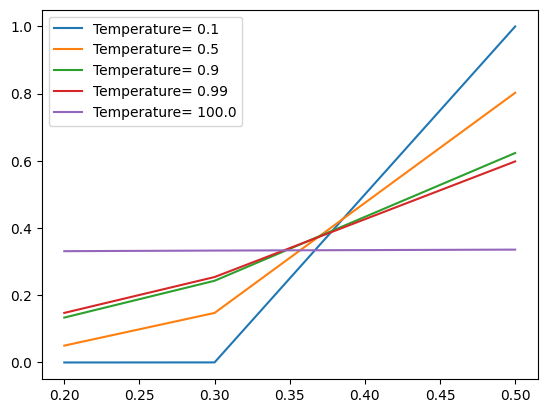

In [62]:
#plot
for t in [0.1, 0.5, 0.9, 0.99, 100.0]:
    plt.plot(p1, [v.data for v in softmax( [x/t for x in logits1] )], label=f"Temperature= {t}")
    plt.legend()

## Build some simple models

Now that we have a framework to generate token sequences from models yielding weights across the tokan vocabulary given the current token, let's 

`logit_model=gpt` is the important argument. `generate` never mentions attention,
embeddings or weights — it only needs *something* it can call for logits, and the
default happens to be the transformer.

`seed` defaults to 42 rather than to system entropy, so a bare `generate(config)`
repeats exactly.

In [146]:
def tokens_to_text(tokens, token_type):
    return ('' if token_type == 'letter' else ' ').join(tokens)

vocabulary = ['A', 'B']
stateless_binary = {
    'uchars' : vocabulary,
    'num_samples' : 3, # How many sequences of tokens should we generate?
    'n_layer' : 1, # Don't worry about it, LLM shit
    'BOS' :2,  # This is the "stop" token, like the end of a word or sentence
    'block_size' : 10, # What's the longest each sequence of tokens can be?
    'vocab_size' : len(vocabulary)+1,
    'token_type' : 'letter'
}


def stateless_binary_model_builder(probs):
    def f(config, token_id, pos_id, keys, values):
        return ([Value(logit(x)) for x in probs])
    return f

def stateful_binary_model_builder(probs_matrix):
    def f(config, token_id, pos_id, keys, values):
        #print(f"Generating probs for {token_id} in {probs_matrix}")
        return ([Value(logit(x)) for x in probs_matrix[token_id]])
    return f

def generate(config, num_samples=20, temperature=0.5, verbose=True, seed=None, logit_model=None):
    """Sample from the model. Returns a list of decoded strings.

    `temperature` is in (0, 1] to control the "creativity" of generated text, low to high.
    """
    seed = 42 if seed is None else seed
    random.seed(seed)
    n_layer, block_size, vocab_size = config['n_layer'], config['block_size'], config['vocab_size']
    uchars, BOS, token_type = config['uchars'], config['BOS'], config['token_type']
    if verbose:
        print(f"Generating {num_samples} samples at T={temperature} with seed {seed}")
    samples = []
    for sample_idx in range(num_samples):
        keys, values = [[] for _ in range(n_layer)], [[] for _ in range(n_layer)]
        token_id = BOS
        sample = []
        for pos_id in range(block_size):
            logits = logit_model(config, token_id, pos_id, keys, values)
            probs = softmax([l / temperature for l in logits])
            
            token_id = random.choices(range(vocab_size), weights=[p.data for p in probs])[0]
            if verbose:
                print(f"{[x.data for x in probs]} -> {token_id}")
            if token_id == BOS:
                break
            sample.append(uchars[token_id])
        text = tokens_to_text(sample, token_type)
        samples.append(text)
        #if verbose:
        #    print(f"sample {sample_idx+1:2d}: {text}")
    return samples

## 1.5 The sampling loop — lines 260–276

Each sample starts from `BOS` with an empty cache and runs until the model emits
`BOS` again or the context window fills.

`temperature` divides the logits before the softmax:

$$
p_i \;=\; \frac{e^{z_i / T}}{\sum_j e^{z_j / T}}
$$

As $T \to 0$ the largest logit dominates and sampling becomes deterministic; at
$T = 1$ the model's own distribution is used unchanged. Values above 1 flatten the
distribution further.

`random.choices` draws one token from that distribution, which is what makes
repeated calls differ. The drawn token becomes the next input, so the sequence is
fed back into itself one position at a time.

Now let's try generating a few different ways - different models we will plug into the generator.

The function provided needs to give the "next token" distribution given the last token generated - which comprises the tokens in the vocabulary and the special BOS token indicating the end of a sequence. 

We'll start with a  simple two-token vocabulary, Heads/Tails, etc. This is simply a marginal distribution across tokens independent of sequence history.

In [144]:
marginal_binary_distribution  = [0.4,0.4, 0.2]

In [147]:
generate(stateless_binary, num_samples=10, temperature=1.0, verbose=False, \
         logit_model = stateless_binary_model_builder( marginal_binary_distribution))

['BAAABB',
 'ABAABAABBA',
 'BBABBAA',
 'AAA',
 'BBBB',
 'ABBB',
 'BBAAAAAAAB',
 'AAAA',
 'BBABAA',
 'BBB']

Now let's allow the next token's distribution to be determined by the current token, a simple 2x2 matrix of transition probabilities. We're setting these to tend to stay on one token for a "run", which we could not do with a marginal distribution on individual tokens:

In [140]:
simple_transitions_dist = [[0.7,0.1, 0.2],[0.1,0.7, 0.2],[0.4,0.4, 0.2], marginal_binary_distribution]

In [142]:
generate(stateless_binary, num_samples=10, temperature=1.0, verbose=False, \
         logit_model = stateful_binary_model_builder( simple_transitions_dist ))

['BAAAA',
 'BBBBA',
 'AAAAA',
 'BBBBA',
 'BBBB',
 'AAAAA',
 'BBB',
 'AAAAA',
 'BBBBB',
 'AAAAA']

Now let's used a more interesting vocabulary - the 27 letters in English. 

In [ ]:

raw_docs = lcgpt.load_docs_textfile('../data/beatles_first3.txt', num_docs=5000, seed=42, verbose=False)
docs = [ s.translate(str.maketrans("", "", string.punctuation)).lower() for s in raw_docs]
uchars = sorted({t for d in docs for t in karpathy.doc_to_tokens(d, 'letter')})

simple_letters_config = {'uchars': uchars, 'vocab_size': len(uchars) + 1, 'BOS': len(uchars),
          'block_size': 8, 'n_layer': 1, 'token_type': 'letter'}

## Generate n-grams for text, make a model

## 1.6 A model made of counts

_Does this all belong in NB2? It's creating a model, not generating with one. We could just import the model from a file - or put the methods in `lcgpt` abd call them = and just show the increasing state and complexity. Or leave it as a nice transisiton to NB2..._

Not from the source. `logit_model` is just a function with the signature
`(config, token_id, pos_id, keys, values) -> logits`, so anything matching it can
drive `generate`. Here it is an n-gram counter, in the spirit of Shannon (1948):
count how often each token follows each context of length $n-1$, and use the log
of those counts as logits.

$$
P(t_i \mid t_{i-n+1}, \ldots, t_{i-1}) \;=\;
\frac{C(t_{i-n+1}, \ldots, t_{i-1}, t_i)}
     {\sum_{t} C(t_{i-n+1}, \ldots, t_{i-1}, t)}
$$

Two details make this fit the interface. The config is built by hand — `generate`
reads only `uchars`, `vocab_size`, `BOS`, `block_size`, `n_layer` and `token_type`,
and there is no `state_dict` because there are no parameters. And the model needs
the tokens it has already produced, which `token_id` alone does not carry: it
appends them to `keys`, the same list the transformer uses for its own cache.

Shannon did this with a book and a pencil. Watch it go from gibberish at $n = 1$ to
plausible names by $n = 4$, before any training has happened. This is the baseline
the GPT has to beat.

In [136]:
def count_ngrams(n):
    """Map every context of length 0..n-1 to a Counter over the tokens that follow it."""
    counts = defaultdict(Counter)
    for doc in docs:
        toks = [BOS] + [uchars.index(t) for t in karpathy.doc_to_tokens(doc, 'letter')] + [BOS]
        for i in range(len(toks) - 1):
            for k in range(n):                  # k = context length
                if i + 1 - k >= 0:
                    counts[tuple(toks[i+1-k:i+1])][toks[i+1]] += 1
    return counts

def make_shannon(n):
    counts = count_ngrams(n)
    def shannon(config, token_id, pos_id, keys, values):
        keys[0].append(token_id)                # the model's own memory of the past
        hist = keys[0]
        for k in range(min(n - 1, len(hist)), -1, -1):   # longest context ever seen
            ctx = tuple(hist[len(hist)-k:])
            if ctx in counts:
                following = counts[ctx]
                return [Value(math.log(following[j])) if following[j] else Value(-1e9)
                        for j in range(V)]
    return shannon

# use an ntuple model for generation
for n in range(1, 10):
    out = generate(config, num_samples=8, temperature=1.0, seed=42,
                   verbose=False, logit_model=make_shannon(n))
    print(f"n={n}: {'  '.join(out)}")

n=1: n darov   h ai aol  amt toe   ye  tntp  l  eltntmo   ad a dne  eacyon p
n=2: r harlo   i gh eng  dat tik   ye burso  myelouyo  s g be h  re f you  cofa
n=3: re goth   i for me  do  ant at a  buter yo  now  oh he ha  ill days
n=4: remember  i do did  done  shake ar  oney  ill shot  do dance  i fine t
n=5: remember  i do da   dont to   you too  my hey h  say hear  roll ove  closer n
n=6: remember  i do and  dont wan  you sha   my heart  say the   roll ove  closer n
n=7: remember  i do and  dont wan  you sha   my heart  say the   roll ove  closer n
n=8: remember  i do all  dont wan  you shou  my heart  say the   roll ove  closer n
n=9: remember  i do all  dont wan  you shou  my heart  say the   roll ove  closer d
